In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [140]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [141]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [142]:
df.shape

(7043, 21)

In [143]:
df.duplicated().sum()

np.int64(0)

In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [145]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [146]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
cols=['Dependents','PhoneService','PaperlessBilling','Churn','gender','Partner']
for col in cols:
    df[col] = label.fit_transform(df[[col]])
df.head()

c:\Users\sweta\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\sweta\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\sweta\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\sweta\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [147]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [148]:
df = df.rename(columns={'gender':'is_male','Partner':'do_partner'})

In [149]:
df['PaperlessBilling'] = label.fit_transform(df['PaperlessBilling'])

In [150]:
df.head()

,customerID,is_male,SeniorCitizen,do_partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [151]:
col = ['OnlineSecurity','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

for c in col:
    df[c] = df[c].map({'No':0,'Yes':1,'No internet service':0})

In [152]:
df.head()

,customerID,is_male,SeniorCitizen,do_partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,0,...,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,1,...,1,0,0,0,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,1,...,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,1,...,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [153]:
df = df.drop(columns=['customerID'])

In [154]:
df.head()

,is_male,SeniorCitizen,do_partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,0,Yes,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,1,No,1,0,0,0,One year,0,Mailed check,56.95,1889.5,0
2,1,0,0,0,2,1,No,DSL,1,Yes,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,1,No,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,0,No,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [155]:
df['OnlineBackup'] = label.fit_transform(df['OnlineBackup'])

In [156]:
df.isna().sum()

is_male             0
SeniorCitizen       0
do_partner          0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [157]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors="coerce")

In [158]:
df['MultipleLines'] = df['MultipleLines'].map({'Yes':1,'No':0,'No phone service':0})

In [159]:
col = df.columns
for c in col:
    print(c,df[c].unique())

is_male [0 1]
SeniorCitizen [0 1]
do_partner [1 0]
Dependents [0 1]
tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService [0 1]
MultipleLines [0 1]
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity [0 1]
OnlineBackup [2 0 1]
DeviceProtection [0 1]
TechSupport [0 1]
StreamingTV [0 1]
StreamingMovies [0 1]
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling [1 0]
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges [  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]
Churn [0 1]


In [160]:
df['OnlineBackup'] = df['OnlineBackup'].map({2:0,0:0,1:1})

In [161]:
numerical_col = ['InternetService','Contract','PaymentMethod']
df = pd.get_dummies(df,columns=numerical_col)

In [162]:
bool_col = df.select_dtypes(include=['bool']).columns
df[bool_col]=df[bool_col].astype(float).astype(int)
df.head()

,is_male,SeniorCitizen,do_partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,0,0,...,1,0,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,1,0,0,0,1,0,0,0,0,1
2,1,0,0,0,2,1,0,1,0,0,...,1,0,0,1,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,...,1,0,0,0,1,0,1,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0


In [163]:
from sklearn.preprocessing import StandardScaler
numeric_col = ['tenure','MonthlyCharges','TotalCharges']
scale = StandardScaler()
df[numeric_col] = scale.fit_transform(df[numeric_col])

In [164]:
df.head()

,is_male,SeniorCitizen,do_partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.277445,0,0,0,0,0,...,1,0,0,1,0,0,0,0,1,0
1,1,0,0,0,0.066327,1,0,1,0,1,...,1,0,0,0,1,0,0,0,0,1
2,1,0,0,0,-1.236724,1,0,1,0,0,...,1,0,0,1,0,0,0,0,0,1
3,1,0,0,0,0.514251,0,0,1,0,1,...,1,0,0,0,1,0,1,0,0,0
4,0,0,0,0,-1.236724,1,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0


In [165]:
df.isna().sum()

is_male                                     0
SeniorCitizen                               0
do_partner                                  0
Dependents                                  0
tenure                                      0
PhoneService                                0
MultipleLines                               0
OnlineSecurity                              0
OnlineBackup                                0
DeviceProtection                            0
TechSupport                                 0
StreamingTV                                 0
StreamingMovies                             0
PaperlessBilling                            0
MonthlyCharges                              0
TotalCharges                               11
Churn                                       0
InternetService_DSL                         0
InternetService_Fiber optic                 0
InternetService_No                          0
Contract_Month-to-month                     0
Contract_One year                 

In [166]:
charges_mean = df['TotalCharges'].mean()
df['TotalCharges']=df['TotalCharges'].fillna(charges_mean)

In [167]:
X = df.drop(columns=['Churn'])
y = df['Churn']

In [168]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   is_male                                  7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   do_partner                               7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   float64
 5   PhoneService                             7043 non-null   int64  
 6   MultipleLines                            7043 non-null   int64  
 7   OnlineSecurity                           7043 non-null   int64  
 8   OnlineBackup                             7043 non-null   int64  
 9   DeviceProtection                         7043 non-null   int64  
 10  TechSupport                              7043 no

In [169]:
X.rename(columns={"Contract_One year": "Contract_One_year", "Contract_Two year": "Contract_Two_year","Contract_Month-to-month": "Contract_Month_to_month","PaymentMethod_Electronic check": "PaymentMethod_Electronic_check","PaymentMethod_Mailed check": "PaymentMethod_Mailed_check","PaymentMethod_Bank transfer (automatic)": "PaymentMethod_Bank_transfer_automatic","PaymentMethod_Credit card (automatic)": "PaymentMethod_Credit_card_automatic","InternetService_DSL": "InternetService_DSL","InternetService_Fiber optic": "InternetService_Fiber_optic","InternetService_No": "InternetService_No"}, inplace=True)

In [170]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.20,random_state=42)


In [171]:
from sklearn.linear_model import LogisticRegression
model_LR = LogisticRegression()

In [172]:
model_LR.fit(X_train,y_train)

LogisticRegression()

In [173]:
y_pred = model_LR.predict(X_test)

In [174]:
from sklearn.metrics import classification_report , confusion_matrix , roc_auc_score , accuracy_score
accuracy_LR = accuracy_score(y_test,y_pred)
print("Accuracy of LR:",accuracy_LR)

Accuracy of LR: 0.8211497515968772


In [175]:
print("Classification_report of Logistic Regression:\n",classification_report(y_test,y_pred))

Classification_report of Logistic Regression:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



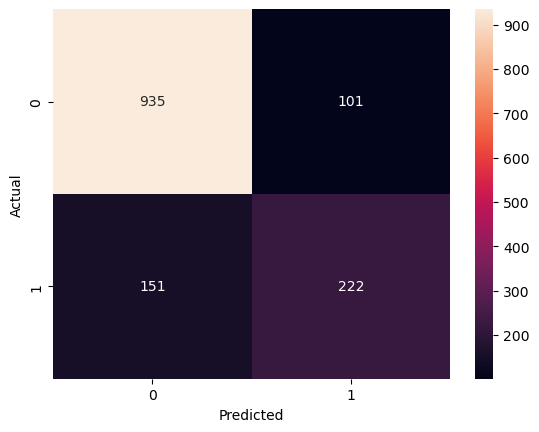

In [176]:
cm =confusion_matrix(y_test,y_pred)


sns.heatmap(cm,annot=True,fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [177]:
y_prob_LR = model_LR.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test,y_prob_LR)
print("ROU-AUC score of Logistic Regression:\n",roc_auc)

ROU-AUC score of Logistic Regression:
 0.8623042326125435


In [178]:
from sklearn.ensemble import RandomForestClassifier
model_RF = RandomForestClassifier(random_state=42)

In [179]:
model_RF.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [180]:
y_pred_RF = model_RF.predict(X_test)

In [181]:
from sklearn.metrics import classification_report , confusion_matrix , roc_auc_score , accuracy_score
accuracy_RF = accuracy_score(y_test,y_pred_RF)
print("Accuracy of RF:",accuracy_RF)

Accuracy of RF: 0.78708303761533


In [182]:
print("Classification_report of Logistic Regression:\n",classification_report(y_test,y_pred_RF))

Classification_report of Logistic Regression:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1036
           1       0.63      0.47      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



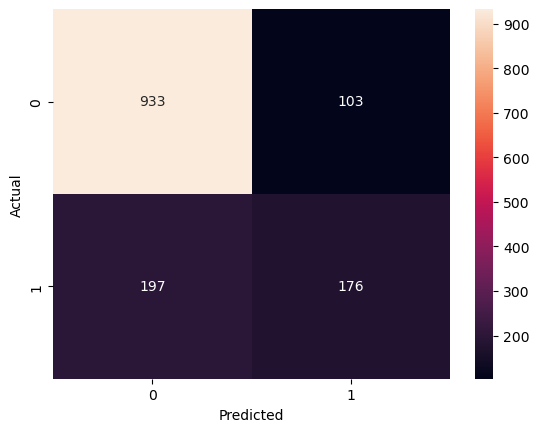

In [183]:
cm =confusion_matrix(y_test,y_pred_RF)


sns.heatmap(cm,annot=True,fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [184]:
y_prob_RF = model_RF.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test,y_prob_RF)
print("ROU-AUC score of Random Forest:\n",roc_auc)

ROU-AUC score of Random Forest:
 0.8372905172503029


In [185]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [186]:
from xgboost import XGBClassifier
model_xgb = XGBClassifier(random_state=42 , n_estimators = 200,max_depth=5,learning_rate=0.05,eval_metric="logloss")

In [187]:
model_xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [188]:
y_pred_xgb = model_xgb.predict(X_test)

In [189]:
from sklearn.metrics import classification_report , confusion_matrix , roc_auc_score , accuracy_score
accuracy_xgb = accuracy_score(y_test,y_pred_xgb)
print("Accuracy of XGB:",accuracy_xgb)

Accuracy of XGB: 0.808374733853797


In [190]:
print("Classification_report of XGB:\n",classification_report(y_test,y_pred_xgb))

Classification_report of XGB:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87      1036
           1       0.67      0.55      0.60       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



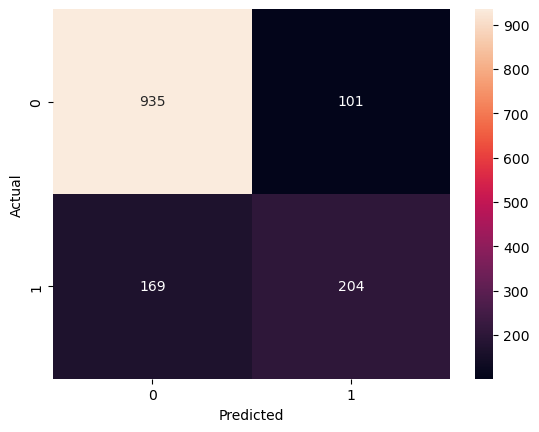

In [191]:
cm =confusion_matrix(y_test,y_pred_xgb)


sns.heatmap(cm,annot=True,fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [192]:
y_prob_xgb = model_xgb.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test,y_prob_xgb)
print("ROU-AUC score of XGB:\n",roc_auc)

ROU-AUC score of XGB:
 0.858127516639581


In [193]:
import os
import joblib

# Create the directory if it doesn't exist
os.makedirs('model/churn_model', exist_ok=True)

# Save the model
joblib.dump(model_LR, 'model/churn_model/model_LR.pkl')

['model/churn_model/model_LR.pkl']

In [194]:
print(X.columns.tolist())

['is_male', 'SeniorCitizen', 'do_partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_DSL', 'InternetService_Fiber_optic', 'InternetService_No', 'Contract_Month_to_month', 'Contract_One_year', 'Contract_Two_year', 'PaymentMethod_Bank_transfer_automatic', 'PaymentMethod_Credit_card_automatic', 'PaymentMethod_Electronic_check', 'PaymentMethod_Mailed_check']
